In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
import xgboost as xgb

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    average_precision_score
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
XGBoost version: 3.2.0


In [5]:
# Source: Arsiwala et al. 2025
# Features to use: HIC RT, SMAC RT, HAC RT, PR Ova, PR CHO, SEC %Monomer, AC-SINS pH 6.0, AC-SINS pH 7.4, Tm1, Tm2, Titer
# Prediction to make: Approved (1) vs Not-Approved (0) — 106 approved, 91 not-approved
# Boostrap 20 independent XGBoost models, random 80:20 train-test splits

df = pd.read_csv('GDPa1_v1.2_20250814.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nClinical status distribution:')
print(df['highest_clinical_trial_asof_feb2025'].value_counts())

Dataset shape: (246, 30)

Clinical status distribution:
highest_clinical_trial_asof_feb2025
Approved                106
Phase-II                 80
Phase-III                39
Phase-I                  13
Preregistration (w)       2
Phase-II/III              2
Preregistration           2
Phase-I/II                1
Approved (withdrawn)      1
Name: count, dtype: int64


In [6]:
FEATURE_COLS = [
    'HIC',           # Hydrophobic interaction chromatography RT
    'SMAC',          # Standup monolayer affinity chromatography RT
    'HAC',           # Heparin affinity chromatography RT
    'PR_Ova',        # Polyreactivity score (ovalbumin)
    'PR_CHO',        # Polyreactivity score (CHO membrane proteins)
    'SEC %Monomer',  # Size-exclusion chromatography % monomer
    'AC-SINS_pH6.0', # Self-association (AC-SINS) at pH 6.0
    'AC-SINS_pH7.4', # Self-association (AC-SINS) at pH 7.4
    'Tm1',           # First melting temperature (nanoDSF)
    'Tm2',           # Second melting temperature (nanoDSF)
    'Titer',         # Expression titer (µg/mL)
]

approved_mask = df['highest_clinical_trial_asof_feb2025'] == 'Approved'
not_approved_mask = ((df['est_status_asof_feb2025'] == 'Discontinued') & ~approved_mask)

df_model = df[approved_mask | not_approved_mask].copy()
df_model['label'] = approved_mask[approved_mask | not_approved_mask].astype(int)

print(f'Antibodies for modeling: {len(df_model)}')
print(f'Approved: {df_model["label"].sum()}')
print(f'Not-approved: {(df_model["label"] == 0).sum()}')

Antibodies for modeling: 198
Approved: 106
Not-approved: 92


In [7]:
X_full = df_model[FEATURE_COLS].copy()
missing_before = X_full.isna().sum().sum()

# Use median for imputation
for col in FEATURE_COLS:
    X_full[col] = X_full[col].fillna(X_full[col].median())

print(f'Missing values imputed: {missing_before}')

y_full = df_model['label'].values
antibody_names_full = df_model['antibody_name'].values

print(f'Feature matrix: {X_full.shape[0]} antibodies, {X_full.shape[1]} features')
print(f'Feature summary: ')
X_full.describe().round(2)

Missing values imputed: 280
Feature matrix: 198 antibodies, 11 features
Feature summary: 


,HIC,SMAC,HAC,PR_Ova,PR_CHO,SEC %Monomer,AC-SINS_pH6.0,AC-SINS_pH7.4,Tm1,Tm2,Titer
count,198.00,198.00,198.00,198.00,198.00,198.00,198.00,198.00,198.00,198.00,198.00
mean,2.83,2.99,3.67,0.11,0.16,95.68,1.85,5.57,70.64,82.45,236.39
std,0.33,0.89,0.72,0.12,0.14,4.10,4.27,7.97,1.96,2.59,110.28
min,2.43,2.68,1.00,0.00,0.00,75.30,-0.40,-1.88,64.05,75.04,34.26
25%,2.58,2.72,3.78,0.02,0.04,94.65,0.35,0.00,69.64,81.40,154.18
50%,2.76,2.75,3.78,0.10,0.14,97.38,0.75,1.50,70.51,82.88,227.63
75%,2.99,2.87,3.78,0.11,0.27,98.24,1.36,10.09,71.64,84.14,301.96
max,4.50,10.00,5.48,0.60,0.55,99.86,30.60,29.50,76.24,88.57,642.34


In [8]:
def build_xgboost_model(random_state = None):
    """
    XGBoost model matching paper hyperparameters.

    Paper XGBoost params:
        max_depth = 25
        learning_rate = 0.25
        n_estimators = 200
        subsample = 0.8
        reg_alpha = 0.1
        reg_lambda = 0.1
    """
    return xgb.XGBClassifier(
        max_depth = 25,
        learning_rate = 0.25,
        n_estimators = 200,
        subsample = 0.8,
        colsample_bytree = 0.8,
        reg_alpha = 0.1,
        reg_lambda = 0.1,
        objective = "binary:logistic",
        eval_metric = "logloss",
        random_state = random_state
    )

def run_bootstrap_models(X, y, n_models=20, test_size=0.2, shuffle_labels=False):
    """
    Train n_models independent classifiers with random 80:20 train-test splits.

    Returns:
      mean_scores: per-sample mean predicted probability (developability score)
      auprc_list:  AUPRC on each model's test set
    """
    all_scores = np.full((len(y), n_models), np.nan)
    auprc_list = []

    for i in range(n_models):
        random_seed = np.random.RandomState(i * 13 + 7)
        y_use = random_seed.permutation(y) if shuffle_labels else y

        # Random 80:20 train-test split WITHOUT replacement (stratified)
        idx_train, idx_test = train_test_split(np.arange(len(y)), test_size=test_size, random_state = random_seed, stratify=y_use)

        # Standardize features (fit on train, transform both)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X.iloc[idx_train])
        X_test_sc = scaler.transform(X.iloc[idx_test])

        # Train and predict
        xgboost_classifier = build_xgboost_model(random_state = i)
        xgboost_classifier.fit(X_train_sc, y_use[idx_train])
        proba = xgboost_classifier.predict_proba(X_test_sc)[:, 1]

        all_scores[idx_test, i] = proba
        auprc_list.append(average_precision_score(y_use[idx_test], proba))

    mean_scores = np.nanmean(all_scores, axis=1)
    return mean_scores, auprc_list


print('Training 20 XGBoost models (true labels)...')
true_scores, true_auprc = run_bootstrap_models(X_full, y_full, n_models = 20)
print(f'Median AUPRC = {np.median(true_auprc):.3f}')

print('Training 20 null hypothesis models (shuffled labels)...')
null_scores, null_auprc = run_bootstrap_models(X_full, y_full, n_models = 20, shuffle_labels = True)
print(f'Median AUPRC = {np.median(null_auprc):.3f}')

Training 20 XGBoost models (true labels)...
Median AUPRC = 0.665
Training 20 null hypothesis models (shuffled labels)...
Median AUPRC = 0.593


In [9]:
print("True label developability scores: ", true_scores)
print("")
print("Null Hypothesis developability scores", null_scores)

True label developability scores:  [0.0210698  0.96791553 0.79321432 0.82986593 0.61893231 0.13790696
 0.23253783 0.39514587        nan 0.02383196 0.17595129 0.98397342
 0.97794836 0.22580722 0.82034914 0.93886609 0.39846587 0.4678435
 0.06887001 0.90919246 0.82644337 0.66715734 0.50670655 0.80052137
 0.05932529 0.35041886 0.03045248 0.50397553 0.38524323 0.09636707
 0.94049688 0.43452362 0.6684756  0.95324538 0.59388799 0.27731567
 0.54187236 0.22059665 0.67558323 0.8953322  0.48835258 0.18385017
 0.21006538 0.77369614 0.66428646 0.99348728 0.76554609 0.97667808
 0.30873929 0.13719416 0.85926582 0.56633338 0.5271966  0.24322328
 0.68119009 0.00567737 0.11380315 0.2975162  0.52199804 0.88700882
 0.16538192 0.86756438 0.52128962 0.90156667 0.92524952 0.34522842
 0.80540117 0.06606029 0.71690203 0.65066354 0.58793615 0.97255412
 0.01916587 0.59503221 0.41406046 0.33984497 0.41038551 0.76228666
 0.00869668 0.54476644 0.02479054 0.32519565 0.46821475 0.13221044
 0.56137001 0.54073276 0.683

In [10]:
results_df = pd.DataFrame({
    'antibody': antibody_names_full,
    'status': df_model['highest_clinical_trial_asof_feb2025'].values,
    'antibody_subtype': df_model['hc_subtype'].values,
    'approved': y_full,
    'developability_score': np.round(true_scores, 3)
}).sort_values('developability_score', ascending = False).reset_index(drop = True)

results_df['approved'] = results_df['approved'].map({1: 'Yes', 0: 'No'})

print('Highest 15 Developability Scores (most likely approved):')
print(results_df.head(15).to_string(index = False))
print("")
print('Lowest 15 Antibody Developability Scores (least likely approved):')
print(results_df.tail(15).to_string(index = False))

Highest 15 Developability Scores (most likely approved):
     antibody   status antibody_subtype approved  developability_score
  dinutuximab Approved             IgG1      Yes                 0.993
 risankizumab Approved             IgG1      Yes                 0.993
 anrukinzumab Phase-II             IgG1       No                 0.984
  racotumomab Approved             IgG1      Yes                 0.983
  tezepelumab Approved             IgG2      Yes                 0.981
   infliximab Approved             IgG1      Yes                 0.980
 atezolizumab Approved             IgG1      Yes                 0.978
   relatlimab Approved             IgG4      Yes                 0.978
 tralokinumab Approved             IgG4      Yes                 0.978
  dostarlimab Approved             IgG4      Yes                 0.977
pembrolizumab Approved             IgG4      Yes                 0.974
 fresolimumab  Phase-I             IgG4       No                 0.973
    nivolumab Approv

In [14]:
# Drop NaN scores
# Any antibodies that were in a test set across the 20 bootstrap models
valid = ~np.isnan(true_scores)
approved_scores = true_scores[valid & (y_full == 1)]
not_approved_scores = true_scores[valid & (y_full == 0)]

null_approved = null_scores[~np.isnan(null_scores) & (y_full == 1)]
null_not_approved = null_scores[~np.isnan(null_scores) & (y_full == 0)]

# Mann-Whitney U test
# Are approved developability significantly higher than non-approved developability scores?
stat, pval = stats.mannwhitneyu(approved_scores, not_approved_scores, alternative = 'greater')

null_rate = np.mean(y_full)

# Pretty print
print('═' * 55)
print('  PROPHET-Ab XGBoost — Key Results')
print('═' * 55)
print(f'\n  Developability Score (mean ± std):')
print(f'  Approved: {np.mean(approved_scores):.3f} ± {np.std(approved_scores):.3f}')
print(f'(Arsiwala paper: 0.6)')
print(f'  Not-Approved: {np.mean(not_approved_scores):.3f} ± {np.std(not_approved_scores):.3f}')
print(f'(Arsiwala paper: 0.49)')
print(f'\n  Mann-Whitney U p-value: {pval:.2e}')
print(f'(paper: 3.5e-5)')
print(f'\n  AUPRC (20 bootstrap models):')
print(f'  True labels: median = {np.median(true_auprc):.3f}  (Arsiwala paper: 0.63)')
print(f'  Null labels: median = {np.median(null_auprc):.3f}  (Arsiwala paper: 0.56)')
print(f'  Null positive rate:    {null_rate:.3f}')
print('═' * 55)

═══════════════════════════════════════════════════════
  PROPHET-Ab XGBoost — Key Results
═══════════════════════════════════════════════════════

  Developability Score (mean ± std):
  Approved: 0.619 ± 0.285
(Arsiwala paper: 0.6)
  Not-Approved: 0.477 ± 0.316
(Arsiwala paper: 0.49)

  Mann-Whitney U p-value: 7.34e-04
(paper: 3.5e-5)

  AUPRC (20 bootstrap models):
  True labels: median = 0.665  (Arsiwala paper: 0.63)
  Null labels: median = 0.593  (Arsiwala paper: 0.56)
  Null positive rate:    0.535
═══════════════════════════════════════════════════════


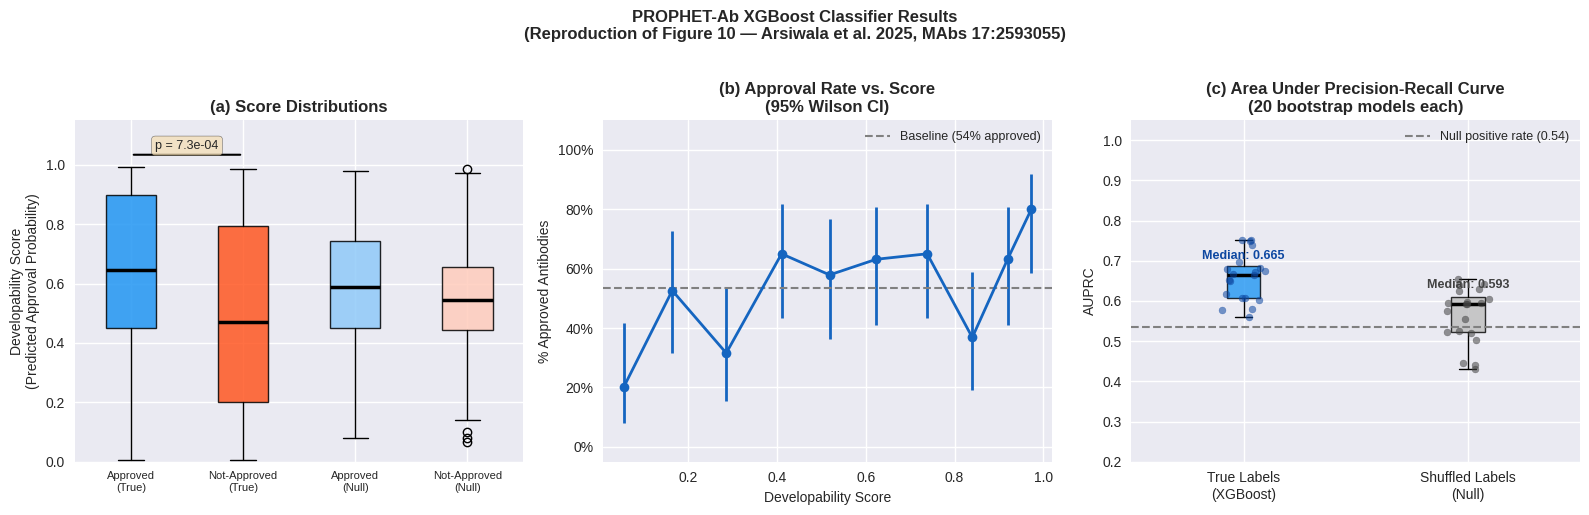

Saved: figure10_reproduction.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'PROPHET-Ab XGBoost Classifier Results\n',
    fontsize = 12, fontweight = 'bold', y=1.02
)

# Panel 1: Score distribution boxplots
ax = axes[0]
groups = [approved_scores, not_approved_scores, null_approved, null_not_approved]

boxplot = ax.boxplot(groups, labels = ['Approved\n(True)', 'Not-Approved\n(True)', 'Approved\n(Null)', 'Not-Approved\n(Null)'], patch_artist = True, medianprops = dict(color = 'black', linewidth = 2.5))

# Random colors
for patch, color in zip(boxplot['boxes'], ['#2196F3', '#FF5722', '#90CAF9', '#FFCCBC']):
    patch.set_facecolor(color); patch.set_alpha(0.85)

ymax = max(np.max(approved_scores), np.max(not_approved_scores))
ax.annotate('', xy = (1, ymax + 0.04), xytext = (2, ymax + 0.04), arrowprops = dict(arrowstyle='-', color = 'black', lw = 1.5))
ax.text(1.5, ymax + 0.06, f'p = {pval:.1e}', ha = 'center', fontsize = 9, bbox = dict(boxstyle = 'round,pad=0.3', facecolor = 'orange', alpha = 0.7))
ax.set_ylabel('Developability Score\n(Predicted Approval Probability)', fontsize = 10)
ax.set_title('Developability Score Distributions', fontweight = 'bold')
ax.tick_params(axis = 'x', labelsize = 8)
ax.set_ylim(0, 1.15)

# Panel 2: Approval rate vs score decile
ax = axes[1]
scores_valid = true_scores[valid]
labels_valid = y_full[valid]

n_bins = 10
pct_edges = np.percentile(scores_valid, np.linspace(0, 100, n_bins + 1))
pct_edges[-1] += 1e-9

bcs, aps, cls, cus = [], [], [], []
for j in range(n_bins):
    mask = (scores_valid >= pct_edges[j]) & (scores_valid < pct_edges[j + 1])
    if mask.sum() == 0:
        continue

    n, k = mask.sum(), labels_valid[mask].sum()
    p_hat = k / n

    # Wilson score interval
    z = 1.96
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2)) / denom
    bcs.append((pct_edges[j] + pct_edges[j + 1]) / 2)
    aps.append(p_hat)
    cls.append(max(0, center - margin))
    cus.append(min(1, center + margin))

ax.errorbar(bcs, aps, yerr = [np.array(aps) - np.array(cls), np.array(cus) - np.array(aps)], fmt = 'o-', color = '#1565C0', capsize = 5, linewidth = 2, markersize = 7)
ax.axhline(null_rate, color = 'gray', linestyle = '--', linewidth = 1.5, label = f'Baseline ({null_rate:.0%} approved)')
ax.set_xlabel('Developability Score', fontsize = 10)
ax.set_ylabel('Percent Approved Antibodies', fontsize = 10)
ax.set_title('Approval Rate vs. Developability Score\n(95% Wilson CI)', fontweight = 'bold')
ax.legend(fontsize = 9)
ax.set_ylim(-0.05, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Panel 3: AUPRC comparison across 20 models
ax = axes[2]
box_plot_2 = ax.boxplot([true_auprc, null_auprc], labels = ['True Labels\n(XGBoost)', 'Shuffled Labels\n(Null)'], patch_artist = True, medianprops = dict(color='black', linewidth = 2.5))
box_plot_2['boxes'][0].set_facecolor('#2196F3')
box_plot_2['boxes'][0].set_alpha(0.8)
box_plot_2['boxes'][1].set_facecolor('#BDBDBD')
box_plot_2['boxes'][1].set_alpha(0.8)

for vals, x, c in [(true_auprc, 1, '#0D47A1'), (null_auprc, 2, '#424242')]:
    jitter = np.random.uniform(-0.1, 0.1, len(vals))
    ax.scatter(np.full(len(vals), x) + jitter, vals, color=c, alpha = 0.55, s = 25, zorder = 3)

ax.axhline(null_rate, color = 'gray', linestyle = '--', linewidth = 1.5, label = f'Null positive rate ({null_rate:.2f})')
ax.set_ylabel('AUPRC', fontsize = 10)
ax.set_title('Area Under Precision-Recall Curve\n(20 bootstrap models each)', fontweight = 'bold')
ax.legend(fontsize = 9)
ax.set_ylim(0.2, 1.05)

for x, vals, c in [(1, true_auprc, '#0D47A1'), (2, null_auprc, '#424242')]:
    ax.text(x, np.median(vals) + 0.04, f'Median: {np.median(vals):.3f}',
            ha = 'center', fontsize = 9, color = c, fontweight = 'bold')

plt.tight_layout()
# plt.savefig('figure10_reproduction.png', bbox_inches = 'tight')
plt.show()
# print('Saved: figure10_reproduction.png')